# Daily Rainfall Estimation and Agricultural Weather Analysis for Anuradhapura, Sri Lanka

**Student:** Sithum Wickramanayaka  
**Student ID:** 269214N  
**Module:** IT5117 - Programming Essentials for Artificial Intelligence

The notebook loads the Anuradhapura weather dataset, checks it, plots the main rainfall patterns, and trains a daily rainfall estimator. Gradient Boosting is the primary model. A two-stage rain/no-rain model is included as an extra comparison.


## 1. Problem definition

Daily rainfall varies considerably in Anuradhapura. That variation affects crop timing, irrigation and water storage.

**Project scope**

- Review the main rainfall and weather patterns in the data.
- Estimate rainfall in millimetres from the available measurements.
- Compare a few standard regression models.
- Add a rain/no-rain stage and check it with classification metrics.

Possible users are farmers, agricultural officers, students and local planners. This is a historical analysis and current-day estimation model, not an operational weather forecast.


## 2. Libraries, variables, and data structures

The main libraries are Pandas and NumPy for data work, Matplotlib for plots, and Scikit-learn for modelling. Project settings, feature names and units are kept in constants, lists and dictionaries so they can be changed in one place.


In [ ]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    accuracy_score,
    ConfusionMatrixDisplay,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
)

warnings.filterwarnings("ignore")

# Variables and common Python data types
DATA_FILE = Path("anuradhapura_daily_weather_2015_2024.csv")
LOCATION_NAME = "Anuradhapura, Sri Lanka"        # string
START_YEAR = 2015                                # integer
TEST_START_YEAR = 2023                           # integer
RANDOM_SEED = 42                                 # integer
RAIN_THRESHOLD_MM = 0.1                          # float
RAIN_EVENT_THRESHOLD_MM = 1.0                    # project-defined meaningful-rain threshold

# Lists store source, primary-model, and extension-model inputs.
SOURCE_WEATHER_FEATURES = [
    "T2M", "T2M_MAX", "T2M_MIN", "T2MDEW", "T2MWET", "RH2M", "QV2M",
    "WS2M", "WD2M", "PS", "ALLSKY_SFC_SW_DWN", "CLOUD_AMT",
]
BASE_FEATURES = [
    "T2M",
    "T2M_MAX",
    "T2M_MIN",
    "RH2M",
    "WS2M",
    "ALLSKY_SFC_SW_DWN",
    "month",
]
FEATURES = BASE_FEATURES + [
    "temp_range",
    "doy_sin",
    "doy_cos",
    "rain_lag_1",
    "rain_lag_2",
    "rain_lag_3",
    "rain_rolling_3",
    "rain_rolling_7",
    "rh_lag_1",
    "solar_lag_1",
]
EXTENDED_FEATURES = FEATURES + [
    "T2MDEW",
    "T2MWET",
    "QV2M",
    "PS",
    "CLOUD_AMT",
    "dew_spread",
    "wind_u",
    "wind_v",
    "pressure_lag_1",
    "cloud_lag_1",
]
TARGET = "PRECTOTCORR"

# A dictionary makes the technical column names easier to understand.
COLUMN_UNITS = {
    "T2M": "°C",
    "T2M_MAX": "°C",
    "T2M_MIN": "°C",
    "T2MDEW": "°C",
    "T2MWET": "°C",
    "RH2M": "%",
    "QV2M": "g/kg",
    "WS2M": "m/s",
    "WD2M": "degrees",
    "PS": "kPa",
    "PRECTOTCORR": "mm/day",
    "ALLSKY_SFC_SW_DWN": "MJ/m²/day",
    "CLOUD_AMT": "%",
}

print(f"Project location: {LOCATION_NAME}")
print(f"Dataset file: {DATA_FILE}")
print(f"Primary regression features: {len(FEATURES)}")
print(f"Two-stage extension features: {len(EXTENDED_FEATURES)}")

Project location: Anuradhapura, Sri Lanka
Dataset file: anuradhapura_daily_weather_2015_2024.csv
Primary regression features: 17
Two-stage extension features: 27


## 3. Data loading

NASA POWER adds a metadata block before the CSV header. The loader scans for `-END HEADER-` instead of assuming a fixed number of rows. It also checks for a missing file, an invalid CSV and missing required columns.


In [ ]:
def find_data_header_row(file_path):
    """Return the row number immediately after the NASA metadata header."""
    try:
        with open(file_path, "r", encoding="utf-8") as file:
            for row_number, line in enumerate(file):
                if line.strip() == "-END HEADER-":
                    return row_number + 1
    except FileNotFoundError as error:
        raise FileNotFoundError(
            f"Dataset not found: {file_path}. Keep the CSV beside this notebook."
        ) from error

    raise ValueError("The NASA '-END HEADER-' marker was not found.")


def load_weather_data(file_path):
    """Load the NASA POWER CSV and perform basic format validation."""
    skip_rows = find_data_header_row(file_path)
    try:
        loaded_data = pd.read_csv(file_path, skiprows=skip_rows)
    except pd.errors.ParserError as error:
        raise ValueError("The dataset could not be parsed as CSV.") from error

    required_columns = {
        "YEAR", "DOY", "T2M", "T2M_MAX", "T2M_MIN", "T2MDEW", "T2MWET",
        "RH2M", "QV2M", "WS2M", "WD2M", "PS", "PRECTOTCORR",
        "ALLSKY_SFC_SW_DWN", "CLOUD_AMT"
    }
    missing_columns = required_columns.difference(loaded_data.columns)
    if missing_columns:
        raise ValueError(f"Required columns are missing: {sorted(missing_columns)}")

    return loaded_data


raw_df = load_weather_data(DATA_FILE)
print(f"Dataset loaded successfully: {raw_df.shape[0]:,} rows × {raw_df.shape[1]} columns")
raw_df.head()

Dataset loaded successfully: 3,653 rows × 15 columns


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2MDEW,T2MWET,RH2M,QV2M,WS2M,WD2M,PS,PRECTOTCORR,ALLSKY_SFC_SW_DWN,CLOUD_AMT
0,2015,1,25.00,28.11,22.59,23.51,24.25,91.68,18.22,1.36,219.9,99.96,3.18,16.56,73.52
1,2015,2,25.04,29.52,21.22,22.70,23.87,87.52,17.32,0.97,185.7,100.19,1.70,18.56,52.27
2,2015,3,24.97,29.31,21.65,22.98,23.98,89.29,17.60,1.41,87.7,100.28,0.86,19.67,42.58
3,2015,4,24.79,29.33,21.38,22.56,23.67,88.00,17.15,1.55,48.5,100.25,1.17,19.70,36.38
4,2015,5,24.64,28.87,21.19,22.78,23.71,89.87,17.39,1.99,30.2,100.21,0.18,20.84,27.85


## 4. Data understanding

Each row is one day at the selected Anuradhapura coordinate. `PRECTOTCORR` is the rainfall target in mm/day, and `DOY` is the day of year. The extra fields—dew point, wet-bulb temperature, specific humidity, wind direction, pressure and cloud amount—are used by the optional extension.


In [ ]:
VARIABLE_DESCRIPTIONS = {
    "YEAR": "Calendar year",
    "DOY": "Day of year",
    "T2M": "Average temperature at 2 metres",
    "T2M_MAX": "Maximum temperature at 2 metres",
    "T2M_MIN": "Minimum temperature at 2 metres",
    "T2MDEW": "Dew or frost point temperature at 2 metres",
    "T2MWET": "Wet-bulb temperature at 2 metres",
    "RH2M": "Relative humidity at 2 metres",
    "QV2M": "Specific humidity at 2 metres",
    "WS2M": "Wind speed at 2 metres",
    "WD2M": "Wind direction at 2 metres",
    "PS": "Surface pressure",
    "PRECTOTCORR": "Corrected daily precipitation (target)",
    "ALLSKY_SFC_SW_DWN": "All-sky surface solar irradiance",
    "CLOUD_AMT": "Cloud amount",
}

description_rows = []
for column_name in raw_df.columns:  # loop
    description_rows.append(
        {
            "Variable": column_name,
            "Description": VARIABLE_DESCRIPTIONS[column_name],
            "Data type": str(raw_df[column_name].dtype),
            "Unit": COLUMN_UNITS.get(column_name, "year/day number"),
        }
    )

data_dictionary = pd.DataFrame(description_rows)
display(data_dictionary)
print("\nDataFrame information:")
raw_df.info()

,Variable,Description,Data type,Unit
0,YEAR,Calendar year,int64,year/day number
1,DOY,Day of year,int64,year/day number
2,T2M,Average temperature at 2 metres,float64,°C
3,T2M_MAX,Maximum temperature at 2 metres,float64,°C
4,T2M_MIN,Minimum temperature at 2 metres,float64,°C
5,T2MDEW,Dew or frost point temperature at 2 metres,float64,°C
6,T2MWET,Wet-bulb temperature at 2 metres,float64,°C
7,RH2M,Relative humidity at 2 metres,float64,%
8,QV2M,Specific humidity at 2 metres,float64,g/kg
9,WS2M,Wind speed at 2 metres,float64,m/s



DataFrame information:
<class 'pandas.DataFrame'>
RangeIndex: 3653 entries, 0 to 3652
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   YEAR               3653 non-null   int64  
 1   DOY                3653 non-null   int64  
 2   T2M                3653 non-null   float64
 3   T2M_MAX            3653 non-null   float64
 4   T2M_MIN            3653 non-null   float64
 5   T2MDEW             3653 non-null   float64
 6   T2MWET             3653 non-null   float64
 7   RH2M               3653 non-null   float64
 8   QV2M               3653 non-null   float64
 9   WS2M               3653 non-null   float64
 10  WD2M               3653 non-null   float64
 11  PS                 3653 non-null   float64
 12  PRECTOTCORR        3653 non-null   float64
 13  ALLSKY_SFC_SW_DWN  3653 non-null   float64
 14  CLOUD_AMT          3653 non-null   float64
dtypes: float64(13), int64(2)
memory usage: 428.2 KB


## 5. Data preparation

Cleaning steps:

1. convert the source columns to numeric values;
2. replace NASA's missing marker (`-999`) with `NaN`;
3. build a date from year and day of year;
4. remove invalid or duplicate dates;
5. remove rows with no rainfall target;
6. fill a missing input with its median;
7. create month, season and simple rainfall-category fields.

The rainfall categories are only used for plots and summaries. They are not official warning levels.


In [ ]:
def rainfall_season(month):
    """Return one of Sri Lanka's four broad rainfall seasons."""
    if month in [3, 4]:
        return "First inter-monsoon"
    elif month in [5, 6, 7, 8, 9]:
        return "South-west monsoon"
    elif month in [10, 11]:
        return "Second inter-monsoon"
    else:
        return "North-east monsoon"


def rainfall_category(rainfall_mm):
    """Create simple project-defined categories for visual exploration."""
    if rainfall_mm < 0.1:
        return "No rain"
    elif rainfall_mm < 10:
        return "Light rain"
    elif rainfall_mm < 25:
        return "Moderate rain"
    else:
        return "Heavy rain"


def prepare_weather_data(data):
    """Clean the weather data and return the prepared data plus a cleaning log."""
    prepared = data.copy()
    cleaning_log = {}

    numeric_columns = list(prepared.columns)
    for column in numeric_columns:  # loop and data type conversion
        prepared[column] = pd.to_numeric(prepared[column], errors="coerce")

    missing_codes = int((prepared == -999).sum().sum())
    prepared = prepared.replace(-999, np.nan)
    cleaning_log["NASA -999 values converted to missing"] = missing_codes

    prepared["date"] = pd.to_datetime(
        prepared["YEAR"].astype("Int64").astype(str)
        + prepared["DOY"].astype("Int64").astype(str).str.zfill(3),
        format="%Y%j",
        errors="coerce",
    )

    invalid_dates = int(prepared["date"].isna().sum())
    prepared = prepared.dropna(subset=["date"])
    cleaning_log["Rows removed due to invalid dates"] = invalid_dates

    duplicate_dates = int(prepared.duplicated(subset=["date"]).sum())
    prepared = prepared.drop_duplicates(subset=["date"])
    cleaning_log["Duplicate dates removed"] = duplicate_dates

    missing_target = int(prepared[TARGET].isna().sum())
    prepared = prepared.dropna(subset=[TARGET])
    cleaning_log["Rows removed due to missing target"] = missing_target

    prepared["month"] = prepared["date"].dt.month
    prepared["year"] = prepared["date"].dt.year
    prepared["rainfall_season"] = prepared["month"].apply(rainfall_season)
    prepared["rainfall_category"] = prepared[TARGET].apply(rainfall_category)

    feature_missing_before = int(prepared[SOURCE_WEATHER_FEATURES].isna().sum().sum())
    for feature in SOURCE_WEATHER_FEATURES:
        if prepared[feature].isna().any():  # conditional statement
            prepared[feature] = prepared[feature].fillna(prepared[feature].median())
    cleaning_log["Missing feature values filled with medians"] = feature_missing_before

    return prepared.sort_values("date").reset_index(drop=True), cleaning_log


df, cleaning_log = prepare_weather_data(raw_df)

print("Cleaning report")
for activity, count in cleaning_log.items():  # loop through dictionary
    print(f"- {activity}: {count}")

print(f"\nPrepared dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Remaining missing values: {int(df.isna().sum().sum())}")

Cleaning report
- NASA -999 values converted to missing: 0
- Rows removed due to invalid dates: 0
- Duplicate dates removed: 0
- Rows removed due to missing target: 0
- Missing feature values filled with medians: 0

Prepared dataset: 3,653 rows × 20 columns
Date range: 2015-01-01 to 2024-12-31
Remaining missing values: 0


In [ ]:
# Confirm the final dataset is logically consistent.
quality_checks = {
    "Unique dates": df["date"].is_unique,
    "Dates in chronological order": df["date"].is_monotonic_increasing,
    "No negative rainfall": bool((df[TARGET] >= 0).all()),
    "No missing source model values": not df[SOURCE_WEATHER_FEATURES + [TARGET]].isna().any().any(),
}

display(pd.DataFrame(
    [{"Quality check": check, "Passed": passed} for check, passed in quality_checks.items()]
))

,Quality check,Passed
0,Unique dates,True
1,Dates in chronological order,True
2,No negative rainfall,True
3,No missing source model values,True


### Data check

No `-999` values, invalid dates, duplicate dates or missing target values were found. The cleaning code is still kept in place so the same workflow can handle another NASA download. Feature scaling is not needed for the tree-based models used here.


## 6. Data exploration and visualisation

The plots below check monthly and yearly rainfall, the rainfall distribution, humidity and the four broad rainfall seasons.


In [ ]:
summary_statistics = df[
    [
        "T2M", "T2M_MAX", "T2M_MIN", "T2MDEW", "RH2M", "QV2M",
        "WS2M", "PS", "CLOUD_AMT", TARGET, "ALLSKY_SFC_SW_DWN",
    ]
].describe().round(2)

display(summary_statistics)

rainy_day_percentage = (df[TARGET] >= RAIN_THRESHOLD_MM).mean() * 100
print(f"Days with at least {RAIN_THRESHOLD_MM} mm rainfall: {rainy_day_percentage:.1f}%")
print(f"Highest daily rainfall: {df[TARGET].max():.2f} mm")

,T2M,T2M_MAX,T2M_MIN,T2MDEW,RH2M,QV2M,WS2M,PS,CLOUD_AMT,PRECTOTCORR,ALLSKY_SFC_SW_DWN
count,3653.00,3653.00,3653.00,3653.00,3653.00,3653.00,3653.00,3653.00,3653.00,3653.00,3653.00
mean,26.94,31.67,23.65,22.70,79.82,17.43,2.95,99.97,67.63,4.17,19.11
std,1.81,2.79,1.78,1.48,8.18,1.51,1.32,0.22,26.01,8.91,4.15
min,21.70,24.27,16.58,15.54,51.46,11.12,0.52,98.92,1.50,0.00,1.90
25%,25.57,29.47,22.75,22.04,73.74,16.68,1.94,99.81,48.13,0.08,16.97
50%,27.05,31.26,23.99,22.95,80.79,17.61,2.67,99.95,71.92,0.68,19.87
75%,28.19,33.60,24.91,23.68,86.36,18.42,3.98,100.13,91.48,4.34,21.98
max,32.39,40.18,27.70,25.99,96.24,21.17,7.14,100.62,99.96,151.99,27.23


Days with at least 0.1 mm rainfall: 73.3%
Highest daily rainfall: 151.99 mm


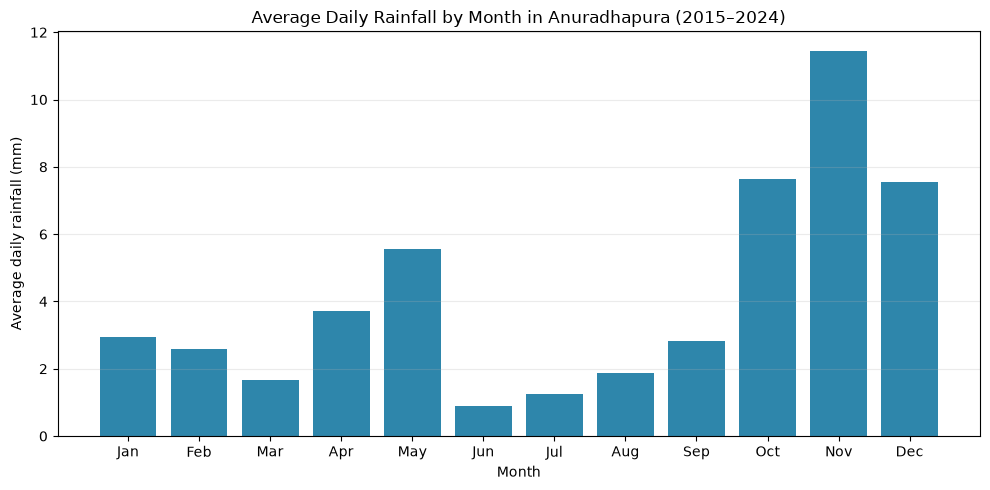

Result: Nov has the highest average daily rainfall at 11.45 mm.


In [ ]:
# Bar chart: average daily rainfall by month
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
monthly_average = df.groupby("month")[TARGET].mean().reindex(range(1, 13))

plt.figure(figsize=(10, 5))
plt.bar(month_names, monthly_average.values, color="#2E86AB")
plt.title("Average Daily Rainfall by Month in Anuradhapura (2015–2024)")
plt.xlabel("Month")
plt.ylabel("Average daily rainfall (mm)")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

wettest_month_number = int(monthly_average.idxmax())
print(
    f"Result: {month_names[wettest_month_number - 1]} has the highest "
    f"average daily rainfall at {monthly_average.max():.2f} mm."
)

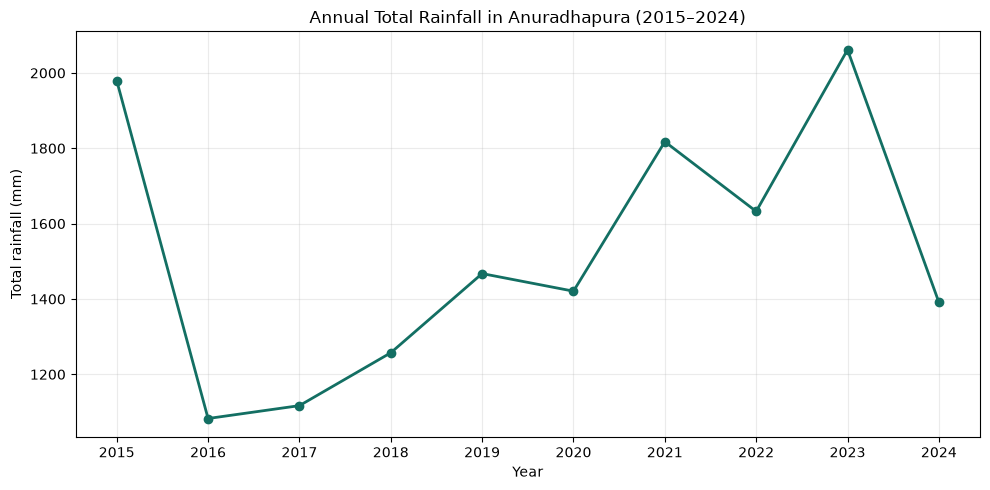

Result: annual rainfall varies across the period. 2023 recorded the highest total of 2061.5 mm.


In [ ]:
# Line chart: total rainfall by year
annual_total = df.groupby("year")[TARGET].sum()

plt.figure(figsize=(10, 5))
plt.plot(annual_total.index, annual_total.values, marker="o", linewidth=2, color="#136F63")
plt.title("Annual Total Rainfall in Anuradhapura (2015–2024)")
plt.xlabel("Year")
plt.ylabel("Total rainfall (mm)")
plt.xticks(annual_total.index)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

wettest_year = int(annual_total.idxmax())
print(
    f"Result: annual rainfall varies across the period. "
    f"{wettest_year} recorded the highest total of {annual_total.max():.1f} mm."
)

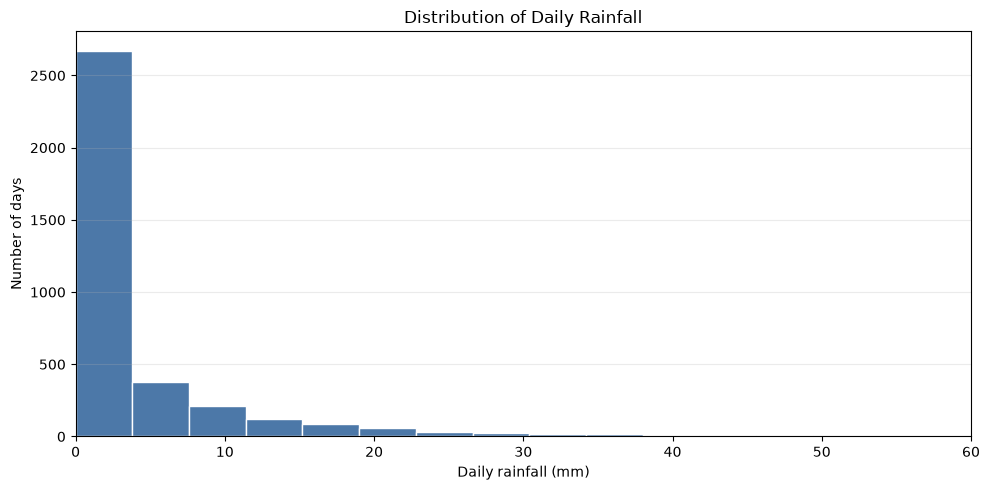

Result: the distribution is right-skewed. Most days have low rainfall, while a small number of days have very high rainfall.


In [ ]:
# Histogram: rainfall distribution
plt.figure(figsize=(10, 5))
plt.hist(df[TARGET], bins=40, color="#4C78A8", edgecolor="white")
plt.title("Distribution of Daily Rainfall")
plt.xlabel("Daily rainfall (mm)")
plt.ylabel("Number of days")
plt.xlim(0, 60)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

print(
    "Result: the distribution is right-skewed. Most days have low rainfall, "
    "while a small number of days have very high rainfall."
)

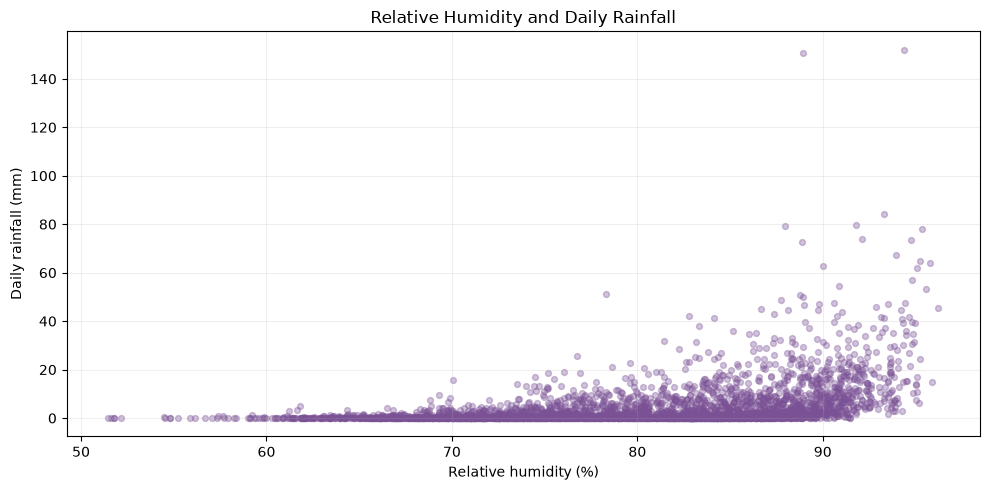

Result: humidity and rainfall have a positive correlation of 0.41, although humidity alone does not explain every rainfall event.


In [ ]:
# Scatter plot: humidity and rainfall
plt.figure(figsize=(10, 5))
plt.scatter(df["RH2M"], df[TARGET], alpha=0.35, s=18, color="#7A5195")
plt.title("Relative Humidity and Daily Rainfall")
plt.xlabel("Relative humidity (%)")
plt.ylabel("Daily rainfall (mm)")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

humidity_correlation = df["RH2M"].corr(df[TARGET])
print(
    f"Result: humidity and rainfall have a positive correlation of "
    f"{humidity_correlation:.2f}, although humidity alone does not explain every rainfall event."
)

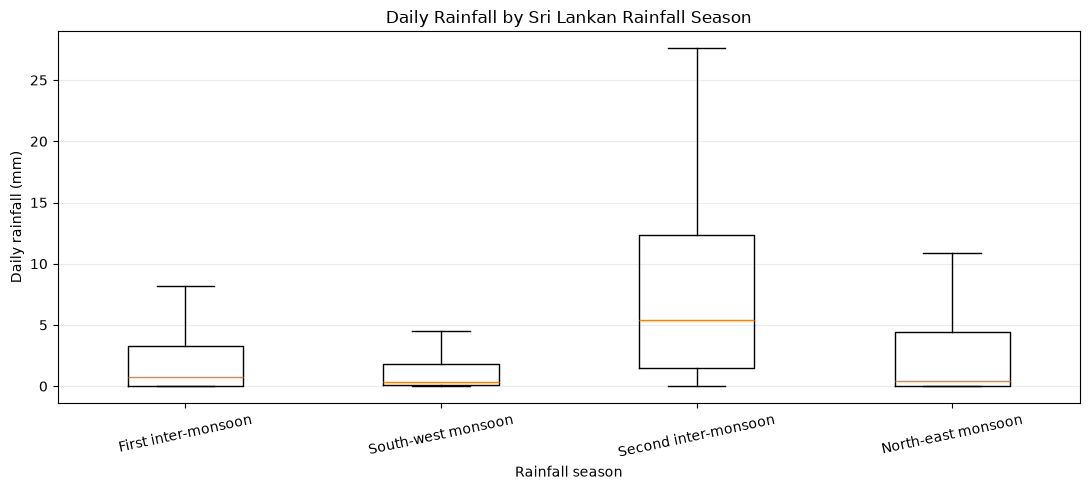

Result: Second inter-monsoon has the highest median daily rainfall (5.37 mm) in this dataset.


In [ ]:
# Box plot: rainfall by Sri Lankan rainfall season
season_order = [
    "First inter-monsoon",
    "South-west monsoon",
    "Second inter-monsoon",
    "North-east monsoon",
]
seasonal_values = [
    df.loc[df["rainfall_season"] == season, TARGET].values
    for season in season_order
]

plt.figure(figsize=(11, 5))
plt.boxplot(seasonal_values, tick_labels=season_order, showfliers=False)
plt.title("Daily Rainfall by Sri Lankan Rainfall Season")
plt.xlabel("Rainfall season")
plt.ylabel("Daily rainfall (mm)")
plt.xticks(rotation=12)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

seasonal_medians = df.groupby("rainfall_season")[TARGET].median().reindex(season_order)
highest_median_season = seasonal_medians.idxmax()
print(
    f"Result: {highest_median_season} has the highest median daily rainfall "
    f"({seasonal_medians.max():.2f} mm) in this dataset."
)

## 7. Basic rainfall-estimation solution

### Feature engineering

The primary model uses the original weather measurements plus:

- temperature range;
- cyclic day-of-year values;
- rainfall from the previous one, two and three days;
- three-day and seven-day rolling rainfall averages;
- previous-day humidity and solar irradiance.

The optional two-stage model also uses dew point, wet-bulb temperature, specific humidity, pressure, cloud amount and two calculated wind-direction components.

All rainfall lag and rolling features start with `shift(1)`, so the current target is not copied into the inputs. Seven rows do not have enough history for the longest rolling feature. Those rows stay in the exploratory analysis but are not used for modelling.


In [ ]:
def create_model_features(data):
    """Create past-only and calendar features for improved rainfall estimation."""
    model_data = data.copy().sort_values("date").reset_index(drop=True)

    model_data["temp_range"] = model_data["T2M_MAX"] - model_data["T2M_MIN"]
    model_data["doy_sin"] = np.sin(2 * np.pi * model_data["DOY"] / 365.25)
    model_data["doy_cos"] = np.cos(2 * np.pi * model_data["DOY"] / 365.25)
    model_data["dew_spread"] = model_data["T2M"] - model_data["T2MDEW"]

    wind_radians = np.deg2rad(model_data["WD2M"])
    model_data["wind_u"] = model_data["WS2M"] * np.sin(wind_radians)
    model_data["wind_v"] = model_data["WS2M"] * np.cos(wind_radians)

    # Shift ensures that today's rainfall is never used to estimate itself.
    model_data["rain_lag_1"] = model_data[TARGET].shift(1)
    model_data["rain_lag_2"] = model_data[TARGET].shift(2)
    model_data["rain_lag_3"] = model_data[TARGET].shift(3)
    model_data["rain_rolling_3"] = model_data[TARGET].shift(1).rolling(3).mean()
    model_data["rain_rolling_7"] = model_data[TARGET].shift(1).rolling(7).mean()
    model_data["rh_lag_1"] = model_data["RH2M"].shift(1)
    model_data["solar_lag_1"] = model_data["ALLSKY_SFC_SW_DWN"].shift(1)
    model_data["pressure_lag_1"] = model_data["PS"].shift(1)
    model_data["cloud_lag_1"] = model_data["CLOUD_AMT"].shift(1)
    model_data["rain_event"] = (
        model_data[TARGET] >= RAIN_EVENT_THRESHOLD_MM
    ).astype(int)

    return model_data.dropna(subset=EXTENDED_FEATURES).reset_index(drop=True)


model_df = create_model_features(df)
print(f"Source records retained for exploration: {len(df):,}")
print(f"Records available for modelling: {len(model_df):,}")
print(f"Rows excluded only because seven-day history was unavailable: {len(df) - len(model_df)}")

Source records retained for exploration: 3,653
Records available for modelling: 3,646
Rows excluded only because seven-day history was unavailable: 7


### Model choice

A `GradientBoostingRegressor` is used as the main model because it gave the lowest test MAE of the three regressors. Huber loss is used to reduce the effect of unusually large rainfall errors.

Model settings were checked using time-ordered validation inside the training period. The final test years were not used while choosing those settings.

- **Training:** 2015–2022
- **Testing:** 2023–2024

The split is chronological so newer records are not mixed into the training data.


In [ ]:
train_df = model_df[model_df["year"] < TEST_START_YEAR].copy()
test_df = model_df[model_df["year"] >= TEST_START_YEAR].copy()

X_train = train_df[FEATURES]
y_train = train_df[TARGET]
X_test = test_df[FEATURES]
y_test = test_df[TARGET]

print(f"Training records: {len(train_df):,} ({train_df['year'].min()}–{train_df['year'].max()})")
print(f"Testing records: {len(test_df):,} ({test_df['year'].min()}–{test_df['year'].max()})")

Training records: 2,915 (2015–2022)
Testing records: 731 (2023–2024)


In [ ]:
model = GradientBoostingRegressor(
    loss="huber",
    learning_rate=0.05,
    n_estimators=300,
    max_depth=3,
    min_samples_leaf=8,
    random_state=RANDOM_SEED,
)

model.fit(X_train, y_train)
predictions = np.maximum(0, model.predict(X_test))

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

model_results = {
    "Mean Absolute Error (mm)": mae,
    "Root Mean Squared Error (mm)": rmse,
    "R-squared": r2,
}

print("Model evaluation on 2023–2024 data")
for metric, value in model_results.items():
    print(f"- {metric}: {value:.3f}")

Model evaluation on 2023–2024 data
- Mean Absolute Error (mm): 2.756
- Root Mean Squared Error (mm): 6.602
- R-squared: 0.524


,Model,MAE (mm),RMSE (mm),R-squared
0,Linear Regression,3.340,6.766,0.500
1,Random Forest,2.880,6.639,0.519
2,Gradient Boosting,2.756,6.602,0.524


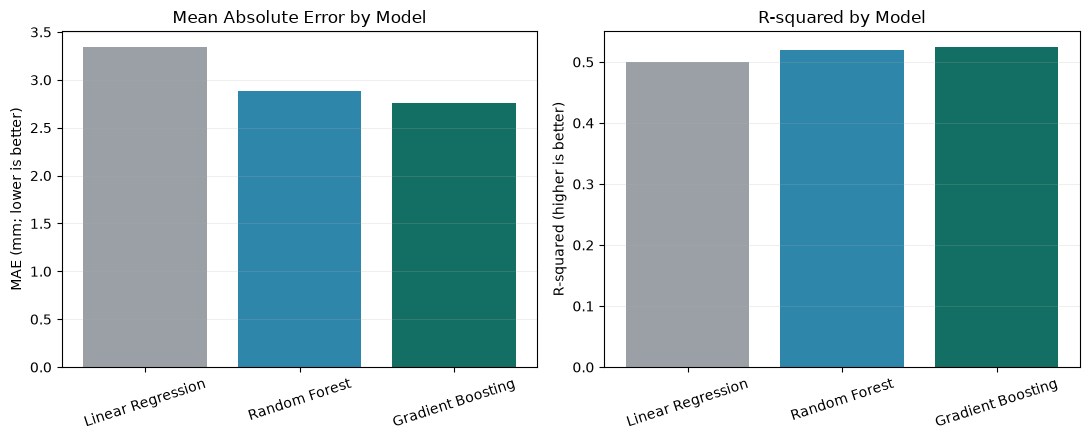

Best test MAE: Gradient Boosting.


In [ ]:
# Compare three understandable regression approaches on the same features and test years.
regression_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=4,
        random_state=RANDOM_SEED,
        n_jobs=-1,
    ),
    "Gradient Boosting": model,
}

comparison_rows = []
regression_predictions = {}
for model_name, candidate_model in regression_models.items():
    candidate_model.fit(X_train, y_train)
    candidate_predictions = np.maximum(0, candidate_model.predict(X_test))
    regression_predictions[model_name] = candidate_predictions
    comparison_rows.append(
        {
            "Model": model_name,
            "MAE (mm)": mean_absolute_error(y_test, candidate_predictions),
            "RMSE (mm)": np.sqrt(mean_squared_error(y_test, candidate_predictions)),
            "R-squared": r2_score(y_test, candidate_predictions),
        }
    )

comparison = pd.DataFrame(comparison_rows).round(3)
display(comparison)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(comparison["Model"], comparison["MAE (mm)"], color=["#9AA0A6", "#2E86AB", "#136F63"])
axes[0].set_title("Mean Absolute Error by Model")
axes[0].set_ylabel("MAE (mm; lower is better)")
axes[0].tick_params(axis="x", rotation=18)
axes[0].grid(axis="y", alpha=0.2)

axes[1].bar(comparison["Model"], comparison["R-squared"], color=["#9AA0A6", "#2E86AB", "#136F63"])
axes[1].set_title("R-squared by Model")
axes[1].set_ylabel("R-squared (higher is better)")
axes[1].tick_params(axis="x", rotation=18)
axes[1].grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

best_mae_model = comparison.loc[comparison["MAE (mm)"].idxmin(), "Model"]
print(f"Result: {best_mae_model} has the lowest test MAE in this comparison.")

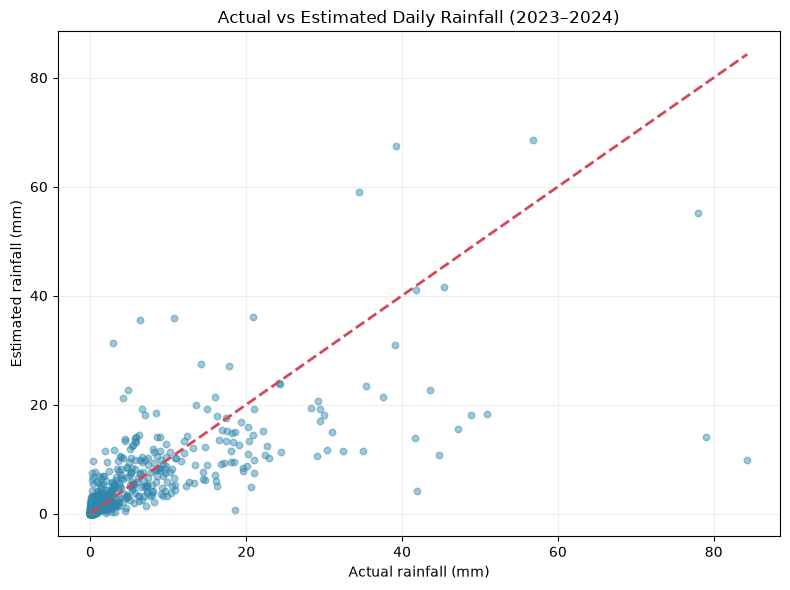

Result: the typical absolute error is 2.76 mm. Points near the dashed line are closer estimates; extreme rainfall remains difficult to estimate.


In [ ]:
# Compare actual and estimated rainfall.
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.45, s=22, color="#2E86AB")
comparison_limit = max(float(y_test.max()), float(predictions.max()))
plt.plot([0, comparison_limit], [0, comparison_limit], "--", color="#D1495B", linewidth=2)
plt.title("Actual vs Estimated Daily Rainfall (2023–2024)")
plt.xlabel("Actual rainfall (mm)")
plt.ylabel("Estimated rainfall (mm)")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print(
    f"Result: the typical absolute error is {mae:.2f} mm. "
    "Points near the dashed line are closer estimates; extreme rainfall remains difficult to estimate."
)

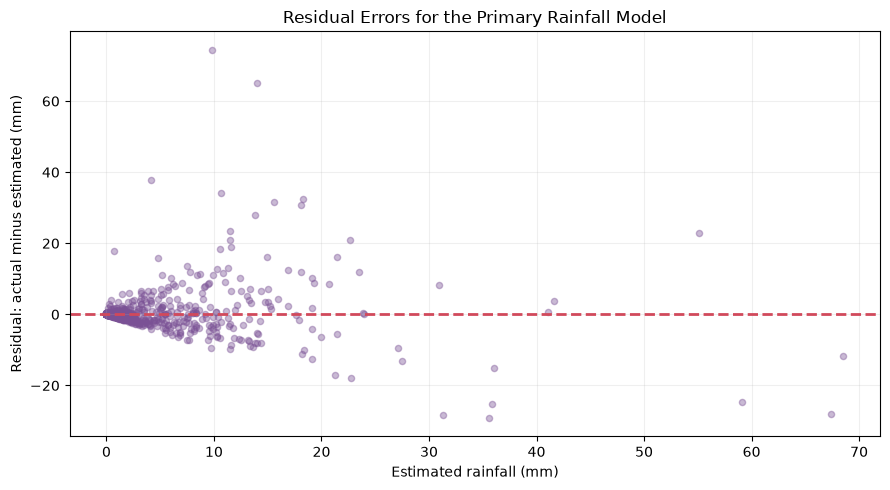

Result: residuals stay close to zero for many low-rainfall days, but the larger positive residuals show that some extreme events are underestimated.


In [ ]:
# Residuals show whether errors change with the estimated rainfall amount.
residuals = y_test.to_numpy() - predictions

plt.figure(figsize=(9, 5))
plt.scatter(predictions, residuals, alpha=0.4, s=20, color="#7A5195")
plt.axhline(0, color="#D1495B", linestyle="--", linewidth=2)
plt.title("Residual Errors for the Primary Rainfall Model")
plt.xlabel("Estimated rainfall (mm)")
plt.ylabel("Residual: actual minus estimated (mm)")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print(
    "Result: residuals stay close to zero for many low-rainfall days, "
    "but the larger positive residuals show that some extreme events are underestimated."
)

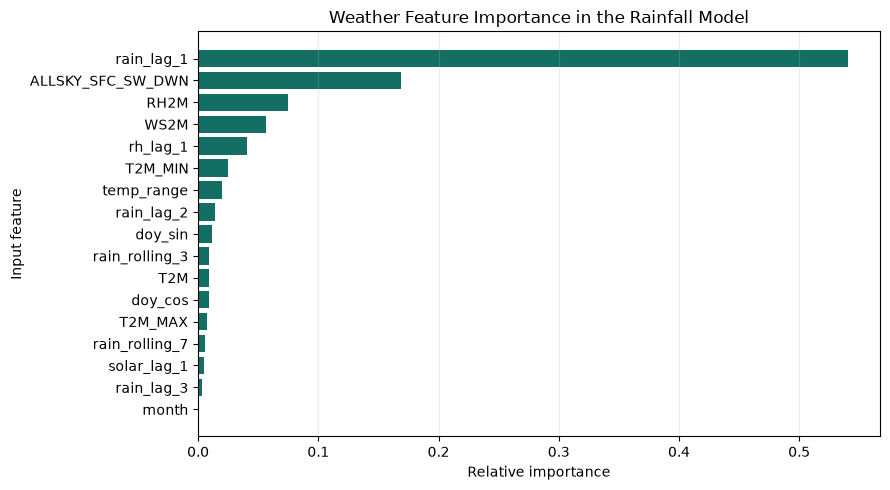

Result: rain_lag_1 has the highest importance in this fitted model. Feature importance describes the model, not direct scientific causation.


In [ ]:
# Determine which model inputs had the greatest influence.
feature_importance = (
    pd.Series(model.feature_importances_, index=FEATURES)
    .sort_values(ascending=True)
)

plt.figure(figsize=(9, 5))
plt.barh(feature_importance.index, feature_importance.values, color="#136F63")
plt.title("Weather Feature Importance in the Rainfall Model")
plt.xlabel("Relative importance")
plt.ylabel("Input feature")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

most_important_feature = feature_importance.idxmax()
print(
    f"Result: {most_important_feature} has the highest importance in this fitted model. "
    "Feature importance describes the model, not direct scientific causation."
)

## 8. Optional two-stage classification and regression extension

Gradient Boosting remains the main regression model. The extension handles rainfall in two steps:

1. **Classification:** is there at least 1.0 mm of rain?
2. **Regression:** if rain is detected, how many millimetres are estimated?

The 1.0 mm cutoff is defined for this project; it is not an official warning level. The first step uses a Random Forest classifier. The second uses Gradient Boosting on `log1p(rainfall)` for rainy training rows. The probability cutoff is selected from 2021–2022 validation data only. The 2023–2024 test set is kept separate.


In [ ]:
# Use 2015–2020 for model selection and 2021–2022 for validation.
selection_train = train_df[train_df["year"] < 2021].copy()
selection_validation = train_df[train_df["year"] >= 2021].copy()

selection_classifier = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
selection_classifier.fit(
    selection_train[EXTENDED_FEATURES], selection_train["rain_event"]
)

selection_rainy = selection_train[selection_train["rain_event"] == 1]
selection_amount_model = GradientBoostingRegressor(
    loss="huber",
    learning_rate=0.05,
    n_estimators=300,
    max_depth=3,
    min_samples_leaf=8,
    random_state=RANDOM_SEED,
)
selection_amount_model.fit(
    selection_rainy[EXTENDED_FEATURES],
    np.log1p(selection_rainy[TARGET]),
)

validation_probability = selection_classifier.predict_proba(
    selection_validation[EXTENDED_FEATURES]
)[:, 1]
validation_amount = np.maximum(
    RAIN_EVENT_THRESHOLD_MM,
    np.expm1(selection_amount_model.predict(selection_validation[EXTENDED_FEATURES])),
)

threshold_results = []
for probability_threshold in np.arange(0.25, 0.81, 0.025):
    validation_class = (validation_probability >= probability_threshold).astype(int)
    validation_combined = np.where(validation_class == 1, validation_amount, 0.0)
    threshold_results.append(
        {
            "Probability threshold": probability_threshold,
            "Validation MAE": mean_absolute_error(
                selection_validation[TARGET], validation_combined
            ),
        }
    )

threshold_table = pd.DataFrame(threshold_results)
best_probability_threshold = float(
    threshold_table.loc[threshold_table["Validation MAE"].idxmin(), "Probability threshold"]
)
print(f"Selected probability threshold from validation data: {best_probability_threshold:.3f}")

Selected probability threshold from validation data: 0.550


,Metric,Value
0,Accuracy,0.862
1,Precision,0.845
2,Recall,0.863
3,F1-score,0.854


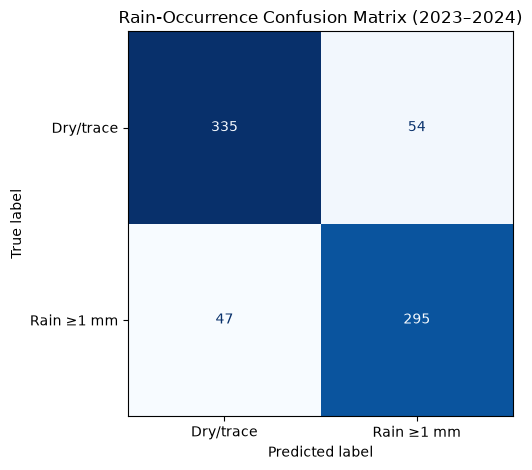

Correct classifications: 335 dry/trace days and 295 rainy days.
Errors: 54 false rain alerts and 47 missed rainy days.


In [ ]:
# Refit both stages using all 2015–2022 training data.
rain_classifier = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
rain_classifier.fit(train_df[EXTENDED_FEATURES], train_df["rain_event"])

rainy_training = train_df[train_df["rain_event"] == 1]
rain_amount_model = GradientBoostingRegressor(
    loss="huber",
    learning_rate=0.05,
    n_estimators=300,
    max_depth=3,
    min_samples_leaf=8,
    random_state=RANDOM_SEED,
)
rain_amount_model.fit(
    rainy_training[EXTENDED_FEATURES], np.log1p(rainy_training[TARGET])
)

rain_probability = rain_classifier.predict_proba(test_df[EXTENDED_FEATURES])[:, 1]
rain_event_predictions = (
    rain_probability >= best_probability_threshold
).astype(int)
rain_amount_predictions = np.maximum(
    RAIN_EVENT_THRESHOLD_MM,
    np.expm1(rain_amount_model.predict(test_df[EXTENDED_FEATURES])),
)
two_stage_predictions = np.where(
    rain_event_predictions == 1, rain_amount_predictions, 0.0
)

actual_rain_events = test_df["rain_event"].to_numpy()
classification_results = pd.DataFrame(
    {
        "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
        "Value": [
            accuracy_score(actual_rain_events, rain_event_predictions),
            precision_score(actual_rain_events, rain_event_predictions),
            recall_score(actual_rain_events, rain_event_predictions),
            f1_score(actual_rain_events, rain_event_predictions),
        ],
    }
).round(3)
display(classification_results)

rain_confusion_matrix = confusion_matrix(actual_rain_events, rain_event_predictions)
ConfusionMatrixDisplay(
    confusion_matrix=rain_confusion_matrix,
    display_labels=["Dry/trace", "Rain ≥1 mm"],
).plot(cmap="Blues", colorbar=False)
plt.title("Rain-Occurrence Confusion Matrix (2023–2024)")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = rain_confusion_matrix.ravel()
print(f"Result: {tn} dry/trace days and {tp} rainy days were classified correctly.")
print(f"Errors: {fp} false rain alerts and {fn} missed rainy days.")

In [ ]:
two_stage_mae = mean_absolute_error(y_test, two_stage_predictions)
two_stage_rmse = np.sqrt(mean_squared_error(y_test, two_stage_predictions))
two_stage_r2 = r2_score(y_test, two_stage_predictions)

solution_comparison = pd.DataFrame(
    {
        "Solution": ["Primary Gradient Boosting", "Optional two-stage extension"],
        "MAE (mm)": [mae, two_stage_mae],
        "RMSE (mm)": [rmse, two_stage_rmse],
        "R-squared": [r2, two_stage_r2],
    }
).round(3)
display(solution_comparison)

segment_definitions = {
    "Dry/trace (<1 mm)": y_test.to_numpy() < 1,
    "Rainy (1 to <20 mm)": (y_test.to_numpy() >= 1) & (y_test.to_numpy() < 20),
    "Heavy (≥20 mm)": y_test.to_numpy() >= 20,
}
segment_rows = []
for segment_name, segment_mask in segment_definitions.items():
    segment_rows.append(
        {
            "Rainfall group": segment_name,
            "Test days": int(segment_mask.sum()),
            "Primary MAE (mm)": mean_absolute_error(
                y_test.to_numpy()[segment_mask], predictions[segment_mask]
            ),
            "Two-stage MAE (mm)": mean_absolute_error(
                y_test.to_numpy()[segment_mask], two_stage_predictions[segment_mask]
            ),
        }
    )

segment_performance = pd.DataFrame(segment_rows).round(3)
display(segment_performance)
print(
    "Result: the two-stage extension improves dry/trace-day estimation and "
    "slightly improves overall MAE and R-squared, while heavy rainfall remains difficult."
)

,Solution,MAE (mm),RMSE (mm),R-squared
0,Primary Gradient Boosting,2.756,6.602,0.524
1,Optional two-stage extension,2.754,6.563,0.530


,Rainfall group,Test days,Primary MAE (mm),Two-stage MAE (mm)
0,Dry/trace (<1 mm),389,0.644,0.518
1,Rainy (1 to <20 mm),297,3.299,3.431
2,Heavy (≥20 mm),45,17.436,17.617


Result: the two-stage model reduces the error on dry/trace days and gives a small overall improvement. Heavy-rainfall errors are still high.


## 9. Reusable rainfall-estimation function

`estimate_rainfall()` is a small wrapper around the fitted primary model. It checks that all required features exist, converts the values to numbers and prevents a negative rainfall result. The example uses the first row from the test set.


In [ ]:
def estimate_rainfall(weather_values, fitted_model):
    """Estimate rainfall from a dictionary containing all required features."""
    missing_inputs = [feature for feature in FEATURES if feature not in weather_values]
    if missing_inputs:
        raise ValueError(f"Missing weather inputs: {missing_inputs}")

    try:
        input_row = pd.DataFrame(
            [[float(weather_values[feature]) for feature in FEATURES]],
            columns=FEATURES,
        )
    except (TypeError, ValueError) as error:
        raise ValueError("Every weather input must be numeric.") from error

    estimated_mm = float(fitted_model.predict(input_row)[0])
    return max(0.0, estimated_mm)


example_weather = X_test.iloc[0].to_dict()
example_estimate = estimate_rainfall(example_weather, model)
example_actual = float(y_test.iloc[0])

print("Example input:", {key: round(value, 2) for key, value in example_weather.items()})
print(f"Estimated rainfall: {example_estimate:.2f} mm")
print(f"Actual rainfall: {example_actual:.2f} mm")

Example input: {'T2M': 23.65, 'T2M_MAX': 27.83, 'T2M_MIN': 20.58, 'RH2M': 87.4, 'WS2M': 2.25, 'ALLSKY_SFC_SW_DWN': 20.1, 'month': 1.0, 'temp_range': 7.25, 'doy_sin': 0.02, 'doy_cos': 1.0, 'rain_lag_1': 0.01, 'rain_lag_2': 0.05, 'rain_lag_3': 0.06, 'rain_rolling_3': 0.04, 'rain_rolling_7': 6.19, 'rh_lag_1': 87.17, 'solar_lag_1': 16.67}
Estimated rainfall: 0.00 mm
Actual rainfall: 0.05 mm


## 10. Conclusion, limitations, and future improvements

### Result summary

- The primary Gradient Boosting model reached an MAE of 2.756 mm and an R-squared value of 0.524.
- The two-stage classifier reached 86.2% accuracy and an F1-score of 0.854.
- The two-stage rainfall estimate had an MAE of 2.754 mm, so the overall regression improvement was small.
- The clearest benefit of the extension was better handling of dry/trace days and the added rain/no-rain result.

### Limitations

- NASA POWER values are gridded estimates and may differ from a local ground station.
- Current-day measurements are inputs, so this is an estimator rather than an advance forecast.
- Heavy rainfall is uncommon and still has the largest errors.
- One coordinate cannot represent the entire Anuradhapura District.
- Changing the project-defined 1.0 mm cutoff will change the classification results.

### Next steps

- Compare the NASA values with verified Sri Lankan ground-station observations.
- Add genuine forecast inputs if advance prediction is required.
- Test more Sri Lankan locations and a longer time period.


## 11. Python concepts demonstrated

| Guideline expectation | Evidence in this notebook |
|---|---|
| Variables and data types | File path, strings, integers, floats, DataFrames |
| Conditional statements | Season/category functions and validation |
| Loops | Header search, type conversion, cleaning log, data dictionary |
| Functions | Loading, preparation, classification, estimation |
| Data structures | Lists, dictionaries, sets, DataFrames |
| File handling | Reading the NASA CSV |
| Exception handling | Missing file, invalid CSV, missing/non-numeric inputs |
| Python libraries | Pandas, NumPy, Matplotlib, Scikit-learn |

## 12. Data source and acknowledgements

- NASA POWER Project, Daily API documentation: https://power.larc.nasa.gov/docs/services/api/temporal/daily/
- NASA POWER parameter dictionary: https://power.larc.nasa.gov/parameters/
- Dataset request: https://power.larc.nasa.gov/api/temporal/daily/point?parameters=T2M,T2M_MAX,T2M_MIN,T2MDEW,T2MWET,RH2M,QV2M,WS2M,WD2M,PS,PRECTOTCORR,ALLSKY_SFC_SW_DWN,CLOUD_AMT&community=AG&longitude=80.4037&latitude=8.3114&start=20150101&end=20241231&format=CSV
- Department of Census and Statistics, Sri Lanka, area and climate information: https://www.statistics.gov.lk/abstract2024/chapter1
- Scikit-learn Gradient Boosting documentation: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html
- Scikit-learn Random Forest documentation (comparison model): https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html
- Scikit-learn Random Forest classifier documentation (optional extension): https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

The dataset was downloaded from NASA POWER.